In [1]:
import numpy as np
import os
from sklearn.metrics import confusion_matrix
import seaborn as sn; sn.set(font_scale=1.4)
from sklearn.utils import shuffle
import matplotlib.pyplot as plt
import cv2
import tensorflow as tf
from tqdm import tqdm 

2026-04-25 04:19:39.200466: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777090779.592634      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777090779.702593      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777090780.683935      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777090780.683974      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777090780.683977      55 computation_placer.cc:177] computation placer alr

In [2]:
class_names=['building','forest','glacier','moutain','sea','street']
class_names_label={class_name:i for i,class_name in enumerate(class_names)}
nb_classes=len(class_names)
IMAGE_SIZE=(150,150)
class_names_label

{'building': 0, 'forest': 1, 'glacier': 2, 'moutain': 3, 'sea': 4, 'street': 5}

In [3]:
 datasets=['/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train'
              ,'/kaggle/input/datasets/puneet6060/intel-image-classification/seg_test']

In [4]:
import os
import cv2
import numpy as np
from tqdm import tqdm

IMAGE_SIZE = (150, 150)

datasets = [
    '/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train',
    '/kaggle/input/datasets/puneet6060/intel-image-classification/seg_test/seg_test'
]

class_names_label = {
    'buildings': 0,
    'forest': 1,
    'glacier': 2,
    'mountain': 3,
    'sea': 4,
    'street': 5
}

def load_data():
    output = []

    for dataset in datasets:
        images = []
        labels = []

        print("Loading {}".format(dataset))

        for folder in os.listdir(dataset):
            folder_path = os.path.join(dataset, folder)

            # تجاهل أي شيء ليس مجلد
            if not os.path.isdir(folder_path):
                continue

            # تأكد أن اسم المجلد موجود في القاموس
            if folder not in class_names_label:
                print(f"Skipping unknown folder: {folder}")
                continue

            label = class_names_label[folder]

            for file in tqdm(os.listdir(folder_path)):
                img_path = os.path.join(folder_path, file)

                image = cv2.imread(img_path)
                if image is None:
                    continue

                image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
                image = cv2.resize(image, IMAGE_SIZE)

                images.append(image)
                labels.append(label)

        images = np.array(images, dtype='float32')
        labels = np.array(labels, dtype='int32')

        output.append((images, labels))

    return output

In [5]:
(train_images,train_labels),(test_image,test_labels)=load_data()

Loading /kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train


100%|██████████| 2404/2404 [00:17<00:00, 135.15it/s]


Loading /kaggle/input/datasets/puneet6060/intel-image-classification/seg_test/seg_test


100%|██████████| 553/553 [00:04<00:00, 129.78it/s]


In [8]:
train_images,train_labels=shuffle(train_images,train_labels,random_state=25)

In [7]:
num_train=train_labels.shape[0]
num_test=test_labels.shape[0]

print('number of traing shape:{}'.format(num_train))
print('number of testing shape:{}'.format(num_test))
print('each image is of size:{}'.format(IMAGE_SIZE))

number of traing shape:14034
number of testing shape:3000
each image is of size:(150, 150)


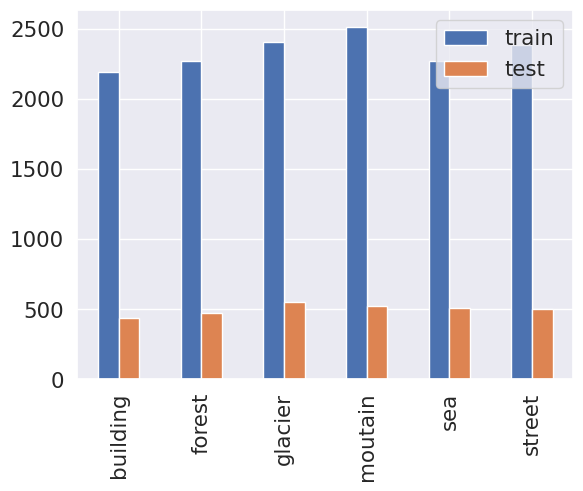

In [9]:
import pandas as pd

train_uniqe,train_counts=np.unique(train_labels,return_counts=True)
test_uniqe,test_counts=np.unique(test_labels,return_counts=True)
pd.DataFrame({'train':train_counts,'test':test_counts},index=class_names).plot.bar()

plt.show()



In [10]:
train_images=train_images/255.0
test_image=test_image/255.0

In [11]:
def display_random_image(class_names,images,labels):
    
    #Display a random image from the image array its corresponed label from the label array.
    
    index=np.random.randint(images.shape[0])
    plt.figure()
    plt.imshow(images[index])
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.title('image #{}: {}'.format(index, class_names[labels[index]]))
    plt.show()



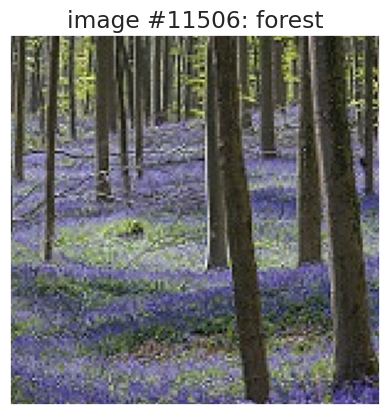

In [12]:
display_random_image(class_names,train_images,train_labels)

float32
0.0
1.0


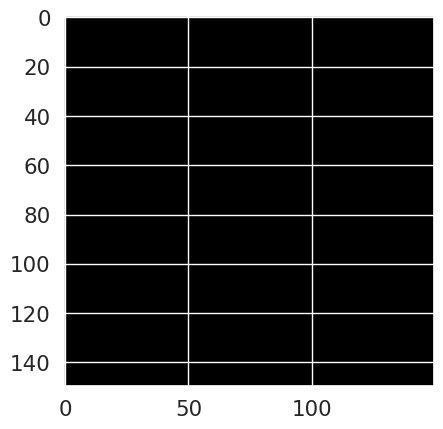

In [13]:
index = np.random.randint(train_images.shape[0])
print(train_images[index].dtype)
print(train_images[index].min())
print(train_images[index].max())
plt.imshow(train_images[index].astype('uint8'))
plt.show()

In [14]:
def display_examples(class_names,images,labels):
    
    #Display a random image from the image array its corresponed label from the label array.

    fig=plt.figure(figsize=(10,10))
    fig.suptitle('some examples of images of dataset',fontsize=16)
    for i in range(25):
    
     plt.subplot(5,5,i+1)
     plt.xticks([])
     plt.yticks([])
     plt.grid(False)
     plt.imshow(images[i],cmap=plt.cm.binary)
     plt.xlabel(class_names[labels[i]])
    
    plt.show()



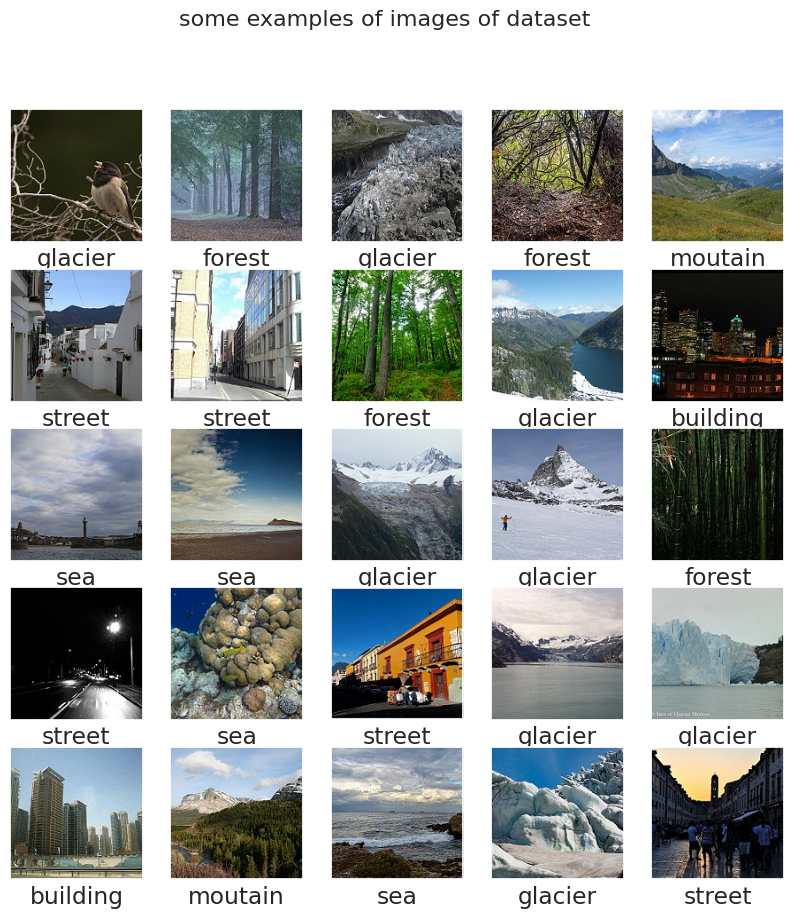

In [15]:
display_examples(class_names,train_images,train_labels)

In [16]:
model=tf.keras.Sequential([

    tf.keras.layers.Conv2D(32,(3,3),activation='relu',input_shape=(150,150,3)),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Conv2D(32,(3,3),activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128,activation=tf.nn.relu),
    tf.keras.layers.Dense(6,activation=tf.nn.softmax)   
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1777091025.567533      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1777091025.573497      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [17]:
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [18]:
history=model.fit(train_images,train_labels,batch_size=128,epochs=20,validation_split=0.2)

Epoch 1/20


I0000 00:00:1777091039.586799     131 service.cc:152] XLA service 0x7872f80067c0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1777091039.586852     131 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1777091039.586859     131 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1777091040.000060     131 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-04-25 04:24:02.712442: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-25 04:24:02.865514: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


 3/88 ━━━━━━━━━━━━━━━━━━━━ 5s 61ms/step - accuracy: 0.2153 - loss: 4.1797

I0000 00:00:1777091047.002615     131 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


87/88 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.4080 - loss: 2.0815

2026-04-25 04:24:13.463440: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-25 04:24:13.612361: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


88/88 ━━━━━━━━━━━━━━━━━━━━ 22s 156ms/step - accuracy: 0.4107 - loss: 2.0656 - val_accuracy: 0.6263 - val_loss: 1.0393
Epoch 2/20
88/88 ━━━━━━━━━━━━━━━━━━━━ 6s 65ms/step - accuracy: 0.6829 - loss: 0.8636 - val_accuracy: 0.7374 - val_loss: 0.7475
Epoch 3/20
88/88 ━━━━━━━━━━━━━━━━━━━━ 6s 65ms/step - accuracy: 0.7514 - loss: 0.6785 - val_accuracy: 0.7581 - val_loss: 0.6713
Epoch 4/20
88/88 ━━━━━━━━━━━━━━━━━━━━ 6s 65ms/step - accuracy: 0.7999 - loss: 0.5634 - val_accuracy: 0.7503 - val_loss: 0.6728
Epoch 5/20
88/88 ━━━━━━━━━━━━━━━━━━━━ 6s 65ms/step - accuracy: 0.8473 - loss: 0.4435 - val_accuracy: 0.7937 - val_loss: 0.5948
Epoch 6/20
88/88 ━━━━━━━━━━━━━━━━━━━━ 6s 66ms/step - accuracy: 0.8929 - loss: 0.3372 - val_accuracy: 0.7895 - val_loss: 0.6218
Epoch 7/20
88/88 ━━━━━━━━━━━━━━━━━━━━ 6s 66ms/step - accuracy: 0.9315 - loss: 0.2237 - val_accuracy: 0.7948 - val_loss: 0.6500
Epoch 8/20
88/88 ━━━━━━━━━━━━━━━━━━━━ 6s 66ms/step - accuracy: 0.9560 - loss: 0.1542 - val_accuracy: 0.7916 - val_loss: 